**Goal:** build a movie recommender from nothing but a table of ratings -- no
recommender library. You will construct the user-item matrix, find similar users
and similar movies with cosine similarity, generate top-N recommendations, and
finish with a small matrix-factorization model whose latent factors are the same
idea you met in L18 (`P @ Q.T`) and L20 (PCA). Pairs with the concept note
[Recommender Systems & Collaborative Filtering](l22_concept_collaborative_filtering.qmd).

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/devomh/cdat4001-2026/blob/main/u06_recommender_systems/l22_lab_collaborative_filtering.ipynb)

> This page is the read-only view. To run the lab, open the notebook
> (`l22_lab_collaborative_filtering.ipynb`) -- in Colab via the badge above, or
> locally. Needs network access the first time (it downloads MovieLens 100k).
> Every text output below comes from actually running the cells.

## Prerequisites & Setup

We use **MovieLens 100k** (GroupLens, University of Minnesota): 100,000 ratings
(1-5 stars) from 943 users on 1,682 movies, plus user demographics and movie
genres. Its license **forbids redistribution**, so -- unlike every other lab in
this course -- we do **not** bundle the data; the notebook downloads it from
GroupLens at run time and checks its md5. Please use it for learning only and
cite Harper & Konstan (2015).

In [1]:
# Setup cell 1 of 2: install only (Colab resets on open; run this first)
%pip install -q pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup cell 2 of 2: imports + download + load. Safe to re-run (skips the download once present).
import os, hashlib, urllib.request, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# MovieLens 100k -- downloaded at run time; NOT redistributed (license forbids it).
URL = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
MD5 = "0e33842e24a9c977be4e0107933c0723"
os.makedirs("data", exist_ok=True)
if not os.path.exists("data/ml-100k/u.data"):
    urllib.request.urlretrieve(URL, "data/ml-100k.zip")
    assert hashlib.md5(open("data/ml-100k.zip", "rb").read()).hexdigest() == MD5, "checksum mismatch"
    with zipfile.ZipFile("data/ml-100k.zip") as z:
        z.extractall("data")

ratings = pd.read_csv("data/ml-100k/u.data", sep="\t", names=["user", "item", "rating", "ts"])
users = pd.read_csv("data/ml-100k/u.user", sep="|", names=["user", "age", "gender", "occupation", "zip"])
GENRES = ["unknown", "Action", "Adventure", "Animation", "Children", "Comedy", "Crime",
          "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror", "Musical", "Mystery",
          "Romance", "Sci-Fi", "Thriller", "War", "Western"]
items = pd.read_csv("data/ml-100k/u.item", sep="|", encoding="latin-1",
                    names=["item", "title", "release", "video", "imdb"] + GENRES)

print("MovieLens 100k -- GroupLens / U. Minnesota (Harper & Konstan 2015); runtime download, not redistributed.")
print("ratings:", ratings.shape, "| users:", users.shape, "| items:", items.shape)

MovieLens 100k -- GroupLens / U. Minnesota (Harper & Konstan 2015); runtime download, not redistributed.
ratings: (100000, 4) | users: (943, 5) | items: (1682, 24)


<details><summary>Expected Output</summary>

~~~text
MovieLens 100k -- GroupLens / U. Minnesota (Harper & Konstan 2015); runtime download, not redistributed.
ratings: (100000, 4) | users: (943, 5) | items: (1682, 24)
~~~
</details>

## Step 1: The Ratings Matrix (Worked)

A recommender starts from one object: the **user-item matrix** $R$, where $R_{ui}$
is the rating user $u$ gave item $i$. Almost every cell is empty -- nobody rates
more than a sliver of all movies. That emptiness (**sparsity**) is the whole
problem.

In [3]:
R = ratings.pivot(index="user", columns="item", values="rating")
R = R.reindex(index=range(1, 944), columns=range(1, 1683))   # full 943 x 1682 grid
n_users, n_items = R.shape
filled = ratings.shape[0]
sparsity = 100 * (1 - filled / (n_users * n_items))
print(f"ratings matrix: {n_users} users x {n_items} movies")
print(f"filled cells: {filled}  ({100 - sparsity:.1f}% filled, {sparsity:.1f}% empty)")

ratings matrix: 943 users x 1682 movies
filled cells: 100000  (6.3% filled, 93.7% empty)


<details><summary>Expected Output</summary>

~~~text
ratings matrix: 943 users x 1682 movies
filled cells: 100000  (6.3% filled, 93.7% empty)
~~~
</details>

Seeing that emptiness helps. The cell below draws a 60x80 corner of the matrix --
blue where a rating exists, white where it is missing.

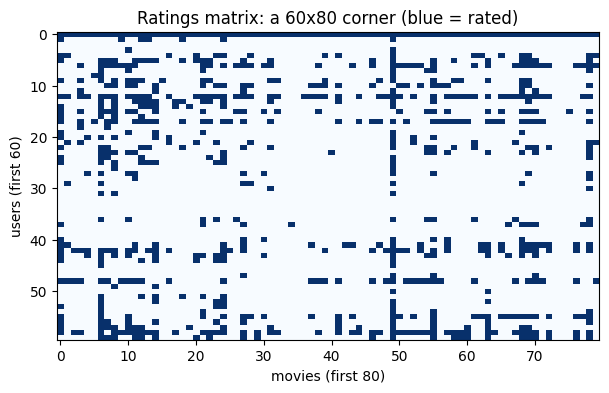

In [4]:
plt.figure(figsize=(7, 4))
plt.imshow(~np.isnan(R.values[:60, :80].astype(float)), aspect="auto", cmap="Blues")
plt.xlabel("movies (first 80)"); plt.ylabel("users (first 60)")
plt.title("Ratings matrix: a 60x80 corner (blue = rated)")
plt.show()

Almost all white: those few blue cells are everything a recommender has to work
with. The denser columns are the popular movies nearly everyone rates; the denser
rows are the most active users.

### Naive approach: just recommend the most popular   <!-- M7: the simple way first -->

The simplest "recommender" ignores *you* entirely and shows everyone the same
crowd-pleasers: the highest-rated movies (with enough ratings to be trustworthy).

In [5]:
stats = ratings.groupby("item").rating.agg(["count", "mean"])
popular = (stats[stats["count"] >= 50]
           .sort_values("mean", ascending=False).head(5)
           .join(items.set_index("item")["title"]))
print(popular[["title", "mean", "count"]].round(2).to_string(index=False))

                                                 title  mean  count
                                 Close Shave, A (1995)  4.49    112
                               Schindler's List (1993)  4.47    298
                            Wrong Trousers, The (1993)  4.47    118
                                     Casablanca (1942)  4.46    243
Wallace & Gromit: The Best of Aardman Animation (1996)  4.45     67


<details><summary>Expected Output</summary>

~~~text
                                                 title  mean  count
                                 Close Shave, A (1995)  4.49    112
                               Schindler's List (1993)  4.47    298
                            Wrong Trousers, The (1993)  4.47    118
                                     Casablanca (1942)  4.46    243
Wallace & Gromit: The Best of Aardman Animation (1996)  4.45     67
~~~
</details>

Fine list -- but it is the *same* for every user. Personalization needs the
ratings of people like you. That is collaborative filtering.

## Step 2: User-User Collaborative Filtering (Worked)

**Collaborative filtering** predicts your taste from the crowd: find users who
rated movies the way you did, then recommend what *they* liked that you have not
seen. "Rated the way you did" needs a similarity measure. We use **cosine
similarity** between two users' rating vectors -- the L18 operation -- but first we
**mean-center** each user (subtract their average) so a generous rater and a harsh
rater can still look similar. Mean-center, then cosine, is exactly L19's Pearson
$r$ between rating vectors. Unrated movies are treated as 0.

In [6]:
Rv = R.values.astype(float)
rated = ~np.isnan(Rv)                       # boolean: which cells have a rating
user_mean = np.nanmean(Rv, axis=1)          # each user's average (over rated movies)
Rc = np.where(rated, Rv - user_mean[:, None], 0.0)   # mean-centered; unrated -> 0
norm = np.sqrt((Rc**2).sum(axis=1)); norm[norm == 0] = 1e-9
sim = (Rc @ Rc.T) / np.outer(norm, norm)    # 943 x 943 cosine similarities (L18 matrix product)
np.fill_diagonal(sim, 0.0)                  # a user is not their own neighbor
print("user-user similarity matrix:", sim.shape)

user-user similarity matrix: (943, 943)


<details><summary>Expected Output</summary>

~~~text
user-user similarity matrix: (943, 943)
~~~
</details>

To recommend for a user: take their $k$ most similar neighbors, and score each
unseen movie by the neighbors' similarity-weighted, mean-centered ratings.

In [7]:
def recommend_user_based(uid, k=30, n=5):
    u = uid - 1                                        # user ids are 1-based
    neighbors = np.argsort(-sim[u])[:k]                # k most similar users
    w = sim[u, neighbors]
    num = w @ Rc[neighbors]                            # weighted sum of their (centered) ratings
    den = np.abs(w) @ rated[neighbors].astype(float)   # total weight that actually rated each movie
    scores = user_mean[u] + np.divide(num, den, out=np.full(n_items, -np.inf), where=den > 0)
    scores[rated[u]] = -np.inf                         # drop movies u already rated
    top = np.argsort(-scores)[:n]
    return [(items.set_index("item").loc[i + 1, "title"], scores[i]) for i in top]

print("top-5 user-user recommendations for user 196:")
for title, score in recommend_user_based(196):
    print(f"{score:.2f}  {title}")

top-5 user-user recommendations for user 196:
5.47  Andre (1994)
5.35  Apartment, The (1960)
5.35  Old Yeller (1957)
5.12  Story of Xinghua, The (1993)
5.12  Bean (1997)


<details><summary>Expected Output</summary>

~~~text
top-5 user-user recommendations for user 196:
5.47  Andre (1994)
5.35  Apartment, The (1960)
5.35  Old Yeller (1957)
5.12  Story of Xinghua, The (1993)
5.12  Bean (1997)
~~~
</details>

> **Interpretation:** these are personalized to user 196's neighbors, not the
> global crowd-pleasers from Step 1. The scores can sit a little above 5 -- they
> are *ranking* scores (a mean plus a weighted bump), not calibrated star
> predictions. For ordering the recommendations, that is exactly what we need.

## Step 3: Item-Item Collaborative Filtering (Worked + Completion)

The other flavor flips the question: instead of "users like you," ask "movies like
the ones you liked." We compute cosine similarity between **movie columns** of the
same centered matrix (note the transpose -- L18's rule for going across columns),
then, for any movie, list its nearest neighbors.

In [8]:
item_norm = np.sqrt((Rc**2).sum(axis=0)); item_norm[item_norm == 0] = 1e-9
S = (Rc.T @ Rc) / np.outer(item_norm, item_norm)   # 1682 x 1682 item-item cosine
np.fill_diagonal(S, 0.0)
print("item-item similarity matrix:", S.shape)

item-item similarity matrix: (1682, 1682)


<details><summary>Expected Output</summary>

~~~text
item-item similarity matrix: (1682, 1682)
~~~
</details>

A movie rated by only a handful of people can look spuriously similar to anything
by chance, so production systems only trust a neighbor with at least a minimum
number of ratings (`min_count`). Our popular movies clear that bar easily.

In [9]:
counts = ratings.groupby("item").rating.count()
title = items.set_index("item")["title"]

def similar_movies(movie_id, n=5, min_count=50):
    i = movie_id - 1
    out = []
    for j in np.argsort(-S[i]):                 # most similar movies first
        if counts.get(j + 1, 0) >= min_count:   # popularity guard
            out.append((title.loc[j + 1], S[i, j]))
        if len(out) >= n:
            break
    return out

print(f"Movies most similar to {title.loc[50]}:")
for t, s in similar_movies(50):
    print(f"{s:.3f}  {t}")

Movies most similar to Star Wars (1977):
0.665  Return of the Jedi (1983)
0.640  Empire Strikes Back, The (1980)
0.564  Raiders of the Lost Ark (1981)
0.386  Godfather, The (1972)
0.372  Princess Bride, The (1987)


<details><summary>Expected Output</summary>

~~~text
Movies most similar to Star Wars (1977):
0.665  Return of the Jedi (1983)
0.640  Empire Strikes Back, The (1980)
0.564  Raiders of the Lost Ark (1981)
0.386  Godfather, The (1972)
0.372  Princess Bride, The (1987)
~~~
</details>

> **Interpretation:** with no idea what any movie *is*, item-item cosine puts the
> two other Star Wars films at the very top -- the rating pattern alone recovers
> the trilogy. This is the engine behind "because you watched...".

**Your completion problem:** find the 5 movies most similar to **Pulp Fiction**
(item id 56). Uncomment, fill the `____`, and run -- you should get a tight cluster
of acclaimed crime dramas.

In [10]:
# for t, s in similar_movies(____, n=5):
#     print(f"{s:.3f}  {t}")

<details><summary>Expected Output (when completed correctly)</summary>

~~~text
0.346  Usual Suspects, The (1995)
0.322  GoodFellas (1990)
0.304  Reservoir Dogs (1992)
0.302  Silence of the Lambs, The (1991)
0.285  One Flew Over the Cuckoo's Nest (1975)
~~~
</details>

## Step 4: Matrix Factorization -- the L18 Matrix Product, Made Real

Comparing whole rating vectors is shallow. **Matrix factorization** instead learns
a short **latent vector** per user and per movie -- a few hidden "taste" axes -- so
that the predicted ratings are a single matrix product $\hat{R} = P\,Q^\top$. First
see the shape of the idea on a tiny hand-built example: 4 users, 5 movies, 2
factors (`action`, `romance`).

In [11]:
P_toy = np.array([[1.0, 0.1],    # Ana  -- action fan
                  [0.1, 1.0],    # Beto -- romance fan
                  [0.9, 0.8],    # Cami -- likes both
                  [0.2, 0.2]])   # Deni -- light viewer
Q_toy = np.array([[1.0, 0.0],    # Die Hard       -- action
                  [0.0, 1.0],    # The Notebook   -- romance
                  [0.8, 0.7],    # Mr & Mrs Smith -- both
                  [0.1, 0.1],    # a documentary  -- neither
                  [0.4, 0.9]])   # a rom-com      -- mostly romance
R_hat_toy = P_toy @ Q_toy.T      # (4 x 2) @ (2 x 5) = 4 users x 5 movies
toy = pd.DataFrame(np.round(R_hat_toy, 2),
                   index=["Ana", "Beto", "Cami", "Deni"],
                   columns=["DieHard", "Notebook", "Smith", "Doc", "RomCom"])
print(toy.to_string())

      DieHard  Notebook  Smith   Doc  RomCom
Ana       1.0       0.1   0.87  0.11    0.49
Beto      0.1       1.0   0.78  0.11    0.94
Cami      0.9       0.8   1.28  0.17    1.08
Deni      0.2       0.2   0.30  0.04    0.26


<details><summary>Expected Output</summary>

~~~text
      DieHard  Notebook  Smith   Doc  RomCom
Ana       1.0       0.1   0.87  0.11    0.49
Beto      0.1       1.0   0.78  0.11    0.94
Cami      0.9       0.8   1.28  0.17    1.08
Deni      0.2       0.2   0.30  0.04    0.26
~~~
</details>

The action fan scores highest on Die Hard, the romance fan on the Notebook and the
rom-com, and the user who likes both tops out on the movie that has both factors --
all from one matrix multiply. Now the real thing: we don't know the factors, so we
**learn** $P$ and $Q$ from the observed ratings by **stochastic gradient descent**
(nudge each factor toward reducing the error on one rating at a time). This trains
on all 100k ratings -- give it up to a minute.

In [12]:
user_ids = {u: k for k, u in enumerate(sorted(ratings.user.unique()))}
item_ids = {i: k for k, i in enumerate(sorted(ratings.item.unique()))}
inv_item = {k: i for i, k in item_ids.items()}
data_arr = np.array([[user_ids[u], item_ids[i], r]
                     for u, i, r in ratings[["user", "item", "rating"]].values])

rng = np.random.default_rng(42)
K, lr, reg, epochs = 20, 0.01, 0.05, 20
P = rng.normal(0, 0.1, (len(user_ids), K))      # user latent factors
Q = rng.normal(0, 0.1, (len(item_ids), K))      # movie latent factors
bu = np.zeros(len(user_ids)); bi = np.zeros(len(item_ids)); gmean = ratings.rating.mean()

for epoch in range(epochs):
    rng.shuffle(data_arr)
    for u, i, r in data_arr:
        u, i = int(u), int(i)
        err = r - (gmean + bu[u] + bi[i] + P[u] @ Q[i])
        bu[u] += lr * (err - reg * bu[u]); bi[i] += lr * (err - reg * bi[i])
        Pu = P[u].copy()
        P[u] += lr * (err * Q[i] - reg * P[u])
        Q[i] += lr * (err * Pu - reg * Q[i])
print(f"trained MF: P {P.shape}, Q {Q.shape}, K={K} latent factors")

trained MF: P (943, 20), Q (1682, 20), K=20 latent factors


<details><summary>Expected Output</summary>

~~~text
trained MF: P (943, 20), Q (1682, 20), K=20 latent factors
~~~
</details>

In [13]:
def recommend_mf(uid, n=5):
    u = user_ids[uid]
    scores = gmean + bu[u] + bi + P[u] @ Q.T        # predict every movie at once (L18 matrix-vector)
    seen = ratings[ratings.user == uid].item.map(item_ids).values
    scores[seen] = -np.inf                          # drop already-rated movies
    top = np.argsort(-scores)[:n]
    return [(items.set_index("item").loc[inv_item[j], "title"], scores[j]) for j in top]

print("top-5 matrix-factorization recommendations for user 196:")
for title, score in recommend_mf(196):
    print(f"{score:.2f}  {title}")
print("user 196 latent vector (first 5 of 20 factors):", np.round(P[user_ids[196]][:5], 2))

top-5 matrix-factorization recommendations for user 196:
4.68  Schindler's List (1993)
4.56  Pather Panchali (1955)
4.55  To Kill a Mockingbird (1962)
4.52  Shawshank Redemption, The (1994)
4.47  Casablanca (1942)
user 196 latent vector (first 5 of 20 factors): [-0.02  0.07 -0.17 -0.03 -0.01]


<details><summary>Expected Output</summary>

~~~text
top-5 matrix-factorization recommendations for user 196:
4.68  Schindler's List (1993)
4.56  Pather Panchali (1955)
4.55  To Kill a Mockingbird (1962)
4.52  Shawshank Redemption, The (1994)
4.47  Casablanca (1942)
user 196 latent vector (first 5 of 20 factors): [-0.02  0.07 -0.17 -0.03 -0.01]
~~~
</details>

> **Interpretation:** 20 learned factors per user and movie give a calibrated
> prediction on the 1-5 scale, and store far less than a 1682 x 1682 similarity
> matrix. Each row of `P` is a user's coordinates in a hidden taste space -- the
> same kind of low-dimensional embedding PCA gave you in L20, now learned directly
> from ratings. **Does it predict held-out ratings better than the neighborhood
> methods?** That is the measurement we make in L23.

## Your Turn (Exercises)

### Exercise 1 -- Recommend for another user

In [14]:
# TODO: pick any user id from 1..943 and print their top-5 user-based
# recommendations (call recommend_user_based).

### Exercise 2 -- Written: the cold-start problem
A brand-new user has just signed up and rated **nothing**. Explain in 2-3
sentences why `recommend_user_based` cannot help them yet, and which approach
from the concept note's family table you would use instead, and why.

## Summary

- A recommender starts from the sparse **user-item matrix** (here 93.7% empty).
- **Collaborative filtering** turns the crowd into personalization via **cosine
  similarity** on mean-centered ratings (= L19's Pearson $r$) -- between users
  (Step 2) or movies (Step 3), with no library.
- A **popularity guard** keeps rarely-rated items from producing spurious matches.
- **Matrix factorization** learns latent user/movie vectors so that
  $\hat{R} = P\,Q^\top$ -- L18's matrix product and L20's PCA idea, applied to
  recommendation.
- We **generated** recommendations but did not yet **measure** them. Next, **L23**
  adds content-, knowledge-, and demographic-based recommenders and shows how to
  evaluate every approach.